In [3]:
import sys
sys.path.append("./helper")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from true_loss_funcs import generate_neg_log_likelihood_4_age, generate_neg_log_likelihood_8_age, generate_neg_log_likelihood_16_age
import pickle

## Best loss after fixed number of iterations

In [4]:
rng = np.random.default_rng(123)
true_phis = [0.97959427, 0.69127489, 0.6611171, 0.71035546]
loss_fn = generate_neg_log_likelihood_4_age(true_phis, rng)
true_loss_4 = loss_fn(true_phis)

rng = np.random.default_rng(123)
true_phis = [0.95737744, 0.67550791, 0.86565616, 0.94441362,
             0.74916310, 0.69556869, 0.57126105, 0.63265584]
loss_fn = generate_neg_log_likelihood_8_age(true_phis, rng)
true_loss_8 = loss_fn(true_phis)

rng = np.random.default_rng(123)
true_phis = [1.72386259, 1.15532378, 1.28441101, 1.4971796,
             0.95784338, 0.90884865, 1.59289604, 0.5372940,
             0.75863593, 1.59368178, 1.14030436, 1.30624542,
             0.88678266, 0.9912558 , 1.0009599 , 1.90459005]
loss_fn = generate_neg_log_likelihood_16_age(true_phis, rng)
true_loss_16 = loss_fn(true_phis)

In [5]:
wd = "seir_4_age_results/fixed_parms/"

with open(wd + "seir_4_age_nm_n_calls.pkl", "rb") as f:
    nm_n_calls_4 = pickle.load(f)
with open(wd + "seir_4_age_nm_saved_x.pkl", "rb") as f:
    nm_saved_x_4 = pickle.load(f)
with open(wd + "seir_4_age_nm_min_nll.pkl", "rb") as f:
    nm_min_nll_4 = pickle.load(f)

with open(wd + "seir_4_age_rf_n_calls.pkl", "rb") as f:
    rf_n_calls_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_saved_x.pkl", "rb") as f:
    rf_saved_x_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_min_nll.pkl", "rb") as f:
    rf_min_nll_4 = pickle.load(f)

with open(wd + "seir_4_age_rf_nm_n_calls.pkl", "rb") as f:
    rf_nm_n_calls_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_nm_saved_x.pkl", "rb") as f:
    rf_nm_saved_x_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_nm_min_nll.pkl", "rb") as f:
    rf_nm_min_nll_4 = pickle.load(f)

wd = "seir_8_age_results/fixed_parms/"

with open(wd + "seir_8_age_nm_n_calls.pkl", "rb") as f:
    nm_n_calls_8 = pickle.load(f)
with open(wd + "seir_8_age_nm_saved_x.pkl", "rb") as f:
    nm_saved_x_8 = pickle.load(f)
with open(wd + "seir_8_age_nm_min_nll.pkl", "rb") as f:
    nm_min_nll_8 = pickle.load(f)

with open(wd + "seir_8_age_rf_n_calls.pkl", "rb") as f:
    rf_n_calls_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_saved_x.pkl", "rb") as f:
    rf_saved_x_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_min_nll.pkl", "rb") as f:
    rf_min_nll_8 = pickle.load(f)

with open(wd + "seir_8_age_rf_nm_n_calls.pkl", "rb") as f:
    rf_nm_n_calls_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_nm_saved_x.pkl", "rb") as f:
    rf_nm_saved_x_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_nm_min_nll.pkl", "rb") as f:
    rf_nm_min_nll_8 = pickle.load(f)

wd = "seir_16_age_results/fixed_parms/"

with open(wd + "seir_16_age_nm_n_calls.pkl", "rb") as f:
    nm_n_calls_16 = pickle.load(f)
with open(wd + "seir_16_age_nm_saved_x.pkl", "rb") as f:
    nm_saved_x_16 = pickle.load(f)
with open(wd + "seir_16_age_nm_min_nll.pkl", "rb") as f:
    nm_min_nll_16 = pickle.load(f)

with open(wd + "seir_16_age_rf_n_calls.pkl", "rb") as f:
    rf_n_calls_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_saved_x.pkl", "rb") as f:
    rf_saved_x_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_min_nll.pkl", "rb") as f:
    rf_min_nll_16 = pickle.load(f)

with open(wd + "seir_16_age_rf_nm_n_calls.pkl", "rb") as f:
    rf_nm_n_calls_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_nm_saved_x.pkl", "rb") as f:
    rf_nm_saved_x_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_nm_min_nll.pkl", "rb") as f:
    rf_nm_min_nll_16 = pickle.load(f)

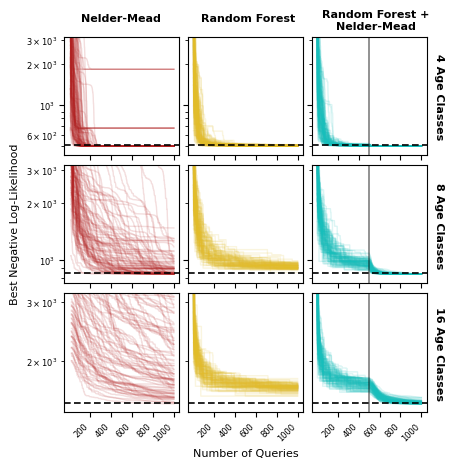

In [7]:
fig, ax = plt.subplots(3, 3, figsize=(5.1, 5), sharex=True)

linewidth = 1.2 # horizontal/vertical lines
linewidth2 = 1 # for the runs
dashes = (4,2)
alpha = 0.15

# 4 age-class results
id = 0
lower = 430
upper = 3200
for i in range(len(nm_n_calls_4)):
    ax[id,0].plot(nm_n_calls_4[i], nm_min_nll_4[i], color="#b22222", alpha=alpha, linewidth=linewidth2)
ax[id,0].axhline(y=true_loss_4, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,0].set_ylim(lower, upper)
ax[id,0].set_yscale("log")
for i in range(len(rf_n_calls_4)):
    ax[id,1].plot(rf_n_calls_4[i], rf_min_nll_4[i], color="#E1BC29", alpha=alpha, linewidth=linewidth2)
ax[id,1].axhline(y=true_loss_4, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,1].set_ylim(lower, upper)
ax[id,1].set_yscale("log")
for i in range(len(rf_nm_n_calls_4)):
    ax[id,2].plot(rf_nm_n_calls_4[i], rf_nm_min_nll_4[i], color="#17BEBB", alpha=alpha, linewidth=linewidth2)
ax[id,2].axhline(y=true_loss_4, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,2].axvline(x=500, color="black", alpha=0.5, linewidth=linewidth)
ax[id,2].set_ylim(lower, upper)
ax[id,2].set_yscale("log")

# 8 age-class results
id = 1
lower = 750
upper = 3200
for i in range(len(nm_n_calls_8)):
    ax[id,0].plot(nm_n_calls_8[i], nm_min_nll_8[i], color="#b22222", alpha=alpha, linewidth=linewidth2)
ax[id,0].axhline(y=true_loss_8, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,0].set_ylim(lower, upper)
ax[id,0].set_yscale("log")
ax[id,0].set_ylabel("Best Negative Log-Likelihood", fontsize=8)
for i in range(len(rf_n_calls_8)):
    ax[id,1].plot(rf_n_calls_8[i], rf_min_nll_8[i], color="#E1BC29", alpha=alpha, linewidth=linewidth2)
ax[id,1].axhline(y=true_loss_8, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,1].set_ylim(lower, upper)
ax[id,1].set_yscale("log")
for i in range(len(rf_nm_n_calls_8)):
    ax[id,2].plot(rf_nm_n_calls_8[i], rf_nm_min_nll_8[i], color="#17BEBB", alpha=alpha, linewidth=linewidth2)
ax[id,2].axhline(y=true_loss_8, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,2].axvline(x=500, color="black", alpha=0.5, linewidth=linewidth)
ax[id,2].set_ylim(lower, upper)
ax[id,2].set_yscale("log")

# 16 age-class results
id = 2
lower = 1410
upper = 3200
for i in range(len(nm_n_calls_16)):
    ax[id,0].plot(nm_n_calls_16[i], nm_min_nll_16[i], color="#b22222", alpha=alpha, linewidth=linewidth2)
ax[id,0].axhline(y=true_loss_16, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,0].set_ylim(lower, upper)
ax[id,0].set_yscale("log")
for i in range(len(rf_n_calls_16)):
    ax[id,1].plot(rf_n_calls_16[i], rf_min_nll_16[i], color="#E1BC29", alpha=alpha, linewidth=linewidth2)
ax[id,1].axhline(y=true_loss_16, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,1].set_ylim(lower, upper)
ax[id,1].set_yscale("log")
ax[id,1].set_xlabel("Number of Queries", fontsize=8)
for i in range(len(rf_nm_n_calls_16)):
    ax[id,2].plot(rf_nm_n_calls_16[i], rf_nm_min_nll_16[i], color="#17BEBB", alpha=alpha, linewidth=linewidth2)
ax[id,2].axhline(y=true_loss_16, color="black", linestyle="--", linewidth=linewidth, dashes=dashes)
ax[id,2].axvline(x=500, color="black", alpha=0.5, linewidth=linewidth)
ax[id,2].set_ylim(lower, upper)
ax[id,2].set_yscale("log")

# Tick label formatting
for i in range(3):
    for j in range(3):
        ax[i,j].tick_params(
            axis='both',
            which='both',
            labelsize=6
        )

    # Hide y-axis tick labels for columns 2 and 3
    ax[i,1].tick_params(axis='y', which='both', labelleft=False)
    ax[i,2].tick_params(axis='y', which='both', labelleft=False)


# X-axis ticks and labels
x_ticks = [200, 400, 600, 800, 1000]

for j in range(3):
    ax[2,j].set_xticks(x_ticks)
    ax[2,j].tick_params(axis='x', labelsize=6)

    for label in ax[2,j].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')



fig.subplots_adjust(
    left=0.16,
    right=0.87,
    bottom=0.15,
    top=0.90,
    wspace=0.08,
    hspace=0.08
)

# Column titles
fig.text(0.27, 0.93, "Nelder-Mead",
         fontsize=8, fontweight="bold", ha="center")

fig.text(0.52, 0.93, "Random Forest",
         fontsize=8, fontweight="bold", ha="center")

fig.text(0.77, 0.915, "Random Forest +\nNelder-Mead",
         fontsize=8, fontweight="bold", ha="center")

# Row titles
fig.text(0.885, 0.779, "4 Age Classes",
         fontsize=8, fontweight="bold", rotation=-90, va="center")

fig.text(0.885, 0.522, "8 Age Classes",
         fontsize=8, fontweight="bold", rotation=-90, va="center")

fig.text(0.885, 0.267, "16 Age Classes",
         fontsize=8, fontweight="bold", rotation=-90, va="center")

plt.savefig(
    "figures/Fig2.tif",
    dpi=300,
    bbox_inches="tight"
)

## Hyperparameter for number of trees in random forest

In [9]:
wd = "seir_4_age_results/fixed_parms/"
with open(wd + "seir_4_age_rf_min_nll_hyperparms_random.pkl", "rb") as f:
    rf_min_nll_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_n_trees_hyperparms_random.pkl", "rb") as f:
    rf_n_trees_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_times_hyperparms_random.pkl", "rb") as f:
    rf_times_4 = pickle.load(f)

wd = "seir_8_age_results/fixed_parms/"
with open(wd + "seir_8_age_rf_min_nll_hyperparms_random.pkl", "rb") as f:
    rf_min_nll_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_n_trees_hyperparms_random.pkl", "rb") as f:
    rf_n_trees_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_times_hyperparms_random.pkl", "rb") as f:
    rf_times_8 = pickle.load(f)

wd = "seir_16_age_results/fixed_parms/"
with open(wd + "seir_16_age_rf_min_nll_hyperparms_random.pkl", "rb") as f:
    rf_min_nll_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_n_trees_hyperparms_random.pkl", "rb") as f:
    rf_n_trees_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_times_hyperparms_random.pkl", "rb") as f:
    rf_times_16 = pickle.load(f)

In [23]:
n_runs = 500
# get the best likelihood value for each run
rf_best_nll_4 = [run[-1] for run in rf_min_nll_4][0:n_runs]
rf_best_nll_8 = [run[-1] for run in rf_min_nll_8][0:n_runs]
rf_best_nll_16 = [run[-1] for run in rf_min_nll_16][0:n_runs]

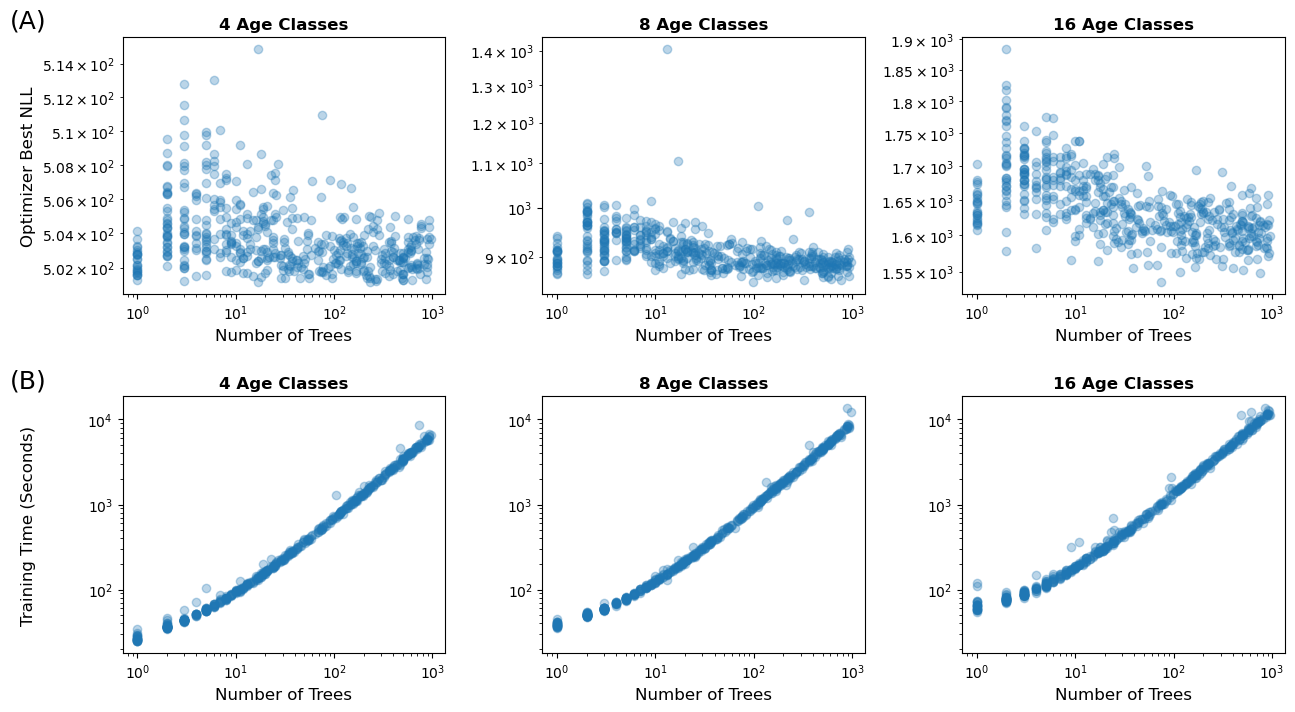

In [24]:
fig = plt.figure(figsize=(15, 8))  # larger height for two rows
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)
alpha = 0.3

# First row: Optimizer Best NLL
ax_top = [fig.add_subplot(gs[0, i]) for i in range(3)]

ax_top[0].scatter(rf_n_trees_4[0:n_runs], rf_best_nll_4, alpha=alpha)
ax_top[0].set_xscale("log")
ax_top[0].set_yscale("log")
ax_top[0].set_xlabel("Number of Trees", fontsize=12)
ax_top[0].set_ylabel("Optimizer Best NLL", fontsize=12)
ax_top[0].set_title("4 Age Classes", fontweight="bold")

ax_top[1].scatter(rf_n_trees_8[0:n_runs], rf_best_nll_8, alpha=alpha)
ax_top[1].set_xscale("log")
ax_top[1].set_yscale("log")
ax_top[1].set_xlabel("Number of Trees", fontsize=12)
ax_top[1].set_title("8 Age Classes", fontweight="bold")

ax_top[2].scatter(rf_n_trees_16[0:n_runs], rf_best_nll_16, alpha=alpha)
ax_top[2].set_xscale("log")
ax_top[2].set_yscale("log")
ax_top[2].set_xlabel("Number of Trees", fontsize=12)
ax_top[2].set_title("16 Age Classes", fontweight="bold")

# Second row: Training Time
# ax_bottom = [fig.add_subplot(gs[1, i], sharex=ax_top[i]) for i in range(3)]
ax_bottom = []
for i in range(3):
    if i == 0:
        ax = fig.add_subplot(gs[1, i], sharex=ax_top[0])
    else:
        ax = fig.add_subplot(gs[1, i], sharex=ax_top[i], sharey=ax_bottom[0])  # share y-axis with first bottom plot
    ax_bottom.append(ax)

ax_bottom[0].scatter(rf_n_trees_4[0:n_runs], rf_times_4[0:n_runs], alpha=alpha)
ax_bottom[0].set_xscale("log")
ax_bottom[0].set_yscale("log")
ax_bottom[0].set_xlabel("Number of Trees", fontsize=12)
ax_bottom[0].set_ylabel("Training Time (Seconds)", fontsize=12)
ax_bottom[0].set_title("4 Age Classes", fontweight="bold")

ax_bottom[1].scatter(rf_n_trees_8[0:n_runs], rf_times_8[0:n_runs], alpha=alpha)
ax_bottom[1].set_xscale("log")
ax_bottom[1].set_yscale("log")
ax_bottom[1].set_xlabel("Number of Trees", fontsize=12)
ax_bottom[1].set_title("8 Age Classes", fontweight="bold")

ax_bottom[2].scatter(rf_n_trees_16[0:n_runs], rf_times_16[0:n_runs], alpha=alpha)
ax_bottom[2].set_xscale("log")
ax_bottom[2].set_yscale("log")
ax_bottom[2].set_xlabel("Number of Trees", fontsize=12)
ax_bottom[2].set_title("16 Age Classes", fontweight="bold")

# add section labels
fig.text(0.05, 0.90, "(A)", fontsize=18, va="center")
fig.text(0.05, 0.45, "(B)", fontsize=18, va="center")

fig.align_ylabels([ax_top[0], ax_bottom[0]])

plt.savefig(
    "figures/S1 Fig.tif",
    dpi=300,
    bbox_inches="tight"
)

## Queries to reach ground-truth NLL

In [25]:
wd = "seir_4_age_results/fixed_parms/"
with open(wd + "seir_4_age_nm_nm_queries_to_true_n_calls.pkl", "rb") as f:
    nm_nm_n_calls_4 = pickle.load(f)
with open(wd + "seir_4_age_rf_nm_queries_to_true_n_calls.pkl", "rb") as f:
    rf_nm_n_calls_4 = pickle.load(f)

wd = "seir_8_age_results/fixed_parms/"
with open(wd + "seir_8_age_nm_nm_queries_to_true_n_calls.pkl", "rb") as f:
    nm_nm_n_calls_8 = pickle.load(f)
with open(wd + "seir_8_age_rf_nm_queries_to_true_n_calls.pkl", "rb") as f:
    rf_nm_n_calls_8 = pickle.load(f)

wd = "seir_16_age_results/fixed_parms/"
with open(wd + "seir_16_age_nm_nm_queries_to_true_n_calls.pkl", "rb") as f:
    nm_nm_n_calls_16 = pickle.load(f)
with open(wd + "seir_16_age_rf_nm_queries_to_true_n_calls.pkl", "rb") as f:
    rf_nm_n_calls_16 = pickle.load(f)

In [27]:
nm_nm_n_calls_total_4 = [np.sum(run) for run in nm_nm_n_calls_4]
nm_nm_n_calls_total_8 = [np.sum(run) for run in nm_nm_n_calls_8]
nm_nm_n_calls_total_16 = [np.sum(run) for run in nm_nm_n_calls_16]

rf_nm_n_calls_total_4 = [np.sum(run) for run in rf_nm_n_calls_4]
rf_nm_n_calls_total_8 = [np.sum(run) for run in rf_nm_n_calls_8]
rf_nm_n_calls_total_16 = [np.sum(run) for run in rf_nm_n_calls_16]

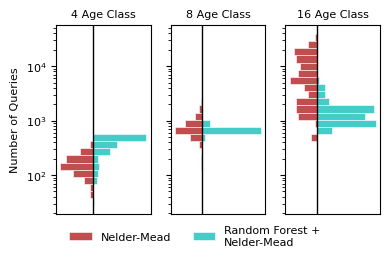

In [28]:
df = pd.DataFrame({
    "value": (
        nm_nm_n_calls_total_4 +
        nm_nm_n_calls_total_8 +
        nm_nm_n_calls_total_16 +
        rf_nm_n_calls_total_4 +
        rf_nm_n_calls_total_8 +
        rf_nm_n_calls_total_16
    ),
    "group": (
        ['Nelder-Mead'] * (
            len(nm_nm_n_calls_total_4) +
            len(nm_nm_n_calls_total_8) +
            len(nm_nm_n_calls_total_16)
        ) +
        ['Random Forest +\nNelder-Mead'] * (
            len(rf_nm_n_calls_total_4) +
            len(rf_nm_n_calls_total_8) +
            len(rf_nm_n_calls_total_16)
        )
    ),
    "n_age": (
        ['4 Age Class'] * len(nm_nm_n_calls_total_4) +
        ['8 Age Class'] * len(nm_nm_n_calls_total_8) +
        ['16 Age Class'] * len(nm_nm_n_calls_total_16) +
        ['4 Age Class'] * len(rf_nm_n_calls_total_4) +
        ['8 Age Class'] * len(rf_nm_n_calls_total_8) +
        ['16 Age Class'] * len(rf_nm_n_calls_total_16)
    )
})


# -------------------------------------------------------
# Plot
# -------------------------------------------------------

fig, axes = plt.subplots(
    1, 3,
    figsize=(4, 2.5),
    sharey=True
)

colors = {
    "Nelder-Mead": "#b22222",
    "Random Forest +\nNelder-Mead": "#17BEBB"
}

age_classes = ['4 Age Class', '8 Age Class', '16 Age Class']

# Use common log-spaced bins so the two distributions are directly comparable
all_values = df["value"].values
bins = np.logspace(
    np.log10(all_values.min()),
    np.log10(all_values.max()),
    25
)

for ax, age in zip(axes, age_classes):

    nm = df[
        (df["n_age"] == age) &
        (df["group"] == "Nelder-Mead")
    ]["value"]

    rf_nm = df[
        (df["n_age"] == age) &
        (df["group"] == "Random Forest +\nNelder-Mead")
    ]["value"]

    # Histogram counts
    nm_counts, _ = np.histogram(nm, bins=bins)
    rf_counts, _ = np.histogram(rf_nm, bins=bins)

    # Bin centers and heights
    centers = np.sqrt(bins[:-1] * bins[1:])
    heights = bins[1:] - bins[:-1]

    # Width of each side of the mirrored histogram
    scale = 0.8 / max(
        nm_counts.max(),
        rf_counts.max()
    )

    nm_width = nm_counts * scale
    rf_width = rf_counts * scale

    # Nelder-Mead -> LEFT
    ax.barh(
        centers,
        -nm_width,
        height=heights,
        color=colors["Nelder-Mead"],
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
        label="Nelder-Mead"
    )

    # Random Forest + Nelder-Mead -> RIGHT
    ax.barh(
        centers,
        rf_width,
        height=heights,
        color=colors["Random Forest +\nNelder-Mead"],
        alpha=0.8,
        edgecolor="white",
        linewidth=0.5,
        label="Random Forest +\nNelder-Mead"
    )

    # Center line
    ax.axvline(
        0,
        color="black",
        linewidth=1
    )

    # Remove histogram-count x-axis
    ax.set_xticks([])

    # Age class title
    ax.set_title(age, fontsize=8)

    # Make the histogram bars touch nicely
    ax.margins(x=0.05)

    ax.set_title(age, fontsize=8)

    ax.tick_params(
        axis="both",
        labelsize=8
    )

    ax.set_yscale("log")

    # Log-scaled query axis
    ax.set_yscale("log")

# Y-axis label
axes[0].set_ylabel("Number of Queries", fontsize=8)

# Put a single legend above the plots
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False,
    fontsize=8
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    "figures/Fig3.tif",
    bbox_inches="tight",
    dpi=300
)